In [1]:
import math
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import chi2, norm

In [2]:
def get_test_quantity(obs, exp):
    '''
    Given observed and expected frequencies, this function returns the test quantity based on which to compute p value
    Args:
        obs (numpy.array, int): vector of observed frequencies
        exp (numpy.array, int): vector of expected frequencies
    Returns:
        the test quantity (float)
    '''
    val = 0
    for i in range(len(obs)):
        val += (obs[i]-exp[i])**2/exp[i]
    return val

In [3]:
def discretize(obs, intervals):
    '''
    Discretizes list of observations into specified buckets (right sided)
    Args:
        obs (numpy.array, float): vector of observations
        intervals (numpy.array, float): vector of values, specifying the bucket ((intervals[0], intervals[1]), (intervals[1], intervals[2]) and so on)
    Returns:
        a count vector representing number of elements (of obs) in each bucket (represented by their right limits) (numpy.array, int)
    '''
    cnt = []
    i, n = 0, len(obs)
    j, m = 1, len(intervals)
    while(i<n):
        temp = 0
        assert(j<m)
        while(i<n and obs[i]<=intervals[j]):
            temp += 1
            i += 1
        cnt.append(temp)
        if(i == n): # data finished
            j += 1 # since data is finished, we move to next interval to record their 0 frequencies
            break
        else: # interval finished
            j += 1
    while(j<m): # all the intervals after data being over have frequency of 0
        cnt.append(0)
        j += 1
    return np.array(cnt)

In [4]:
def get_p_val(data, num_intervals, lb, ub):
    '''
    Returns p_value for Uniform[lb, ub] distribution
    Args:
        data (numpy.array, float): vector of data points
        num_intervals (int): number of intervals for discretizing data
        lb (float): lower bound of the uniform distribution
        ub (float): upper bound of the uniform distribution
    Returns:
        p_value (float, (0, 1))
    '''
    N = len(data)
    obs = np.sort(data)

    intervals = np.array([i*(ub-lb)/num_intervals + lb for i in range(num_intervals+1)])

    obs = discretize(obs, intervals) # masses assigned to the right boundaries of the intervals
    
    exp = N*np.array([1/num_intervals for _ in range(num_intervals)])

    t = get_test_quantity(obs, exp)
    d = chi2(num_intervals-1)
    return 1-d.cdf(t)

In [5]:
def F_exp(x, lmda):
    '''
    returns cdf of exp(lmda)
    Args:
        x (float): the point to evaluate the cdf on
        lmda (float): exponential distribution parameter
    Returns:
        cdf value (float, between 0 and 1)
    '''
    return 1-math.exp(-lmda*x)

def F_unif(x):
    '''
    returns cdf of U[0, 1]
    Args:
        x (float): the point to evaluate the cdf on
    Returns:
        cdf value (float, between 0 and 1)
    '''
    return x

def compute_max_difference(data_sorted, F):
    '''
    Given sorted data values, this function computes the maximum difference betweeen the empirical distribution and its theoretical distribution (F)
    Args:
        data_sorted (numpy.array, float): sorted vector of data values
        F (function): Cdf distribution
    Returns:
        the maximum difference (float, >= 0)
    Caution: the data values must be from the domain of F
    '''
    N = len(data_sorted)
    d = 0
    for j in range(N):
        d = max(d, (j+1)/N - F(data_sorted[j]))
    for j in range(N):
        d = max(d, F(data_sorted[j]) - j/N)
    return d

In [6]:
def generate_binomial(n, p):
    '''
    Generates a binomial random variable, given the parameters (using just 1 U[0, 1])
    Args:
        n (int): total number of draws
        p (float): probability of success
    Returns:
        a realization of Bin(n, p) (int, [0, n])
    '''
    ans = 0
    u = np.random.rand()
    for i in range(n):
        if(u<p):
            ans += 1
            u = u/p
        else:
            u = (u-p)/(1-p)
    return ans

In [12]:
def get_prob_dp_memoize(n, m, r, Pmat):
    '''
    Compute the probability that the Rank sum RV <= r when first and second set are of length n and m
    Computation done recursively; memoization also used
    Args:
        n (int): length of group 1
        m (int): length of group 2
        r (int): the current realization of rank sum of group 1
        Pmat (dict[tuple[int, int, int], float]): A dictionary storing all the values computed till now (memoization base)
    Returns:
        the required probability (float, [0, 1])
    '''
    tup = (n, m, r)
    if(Pmat.get(tup)!=None):
        return Pmat[tup]
    if (n == 0):
        if(r<0):
            Pmat[tup] = 0
        else:
            Pmat[tup] = 1
    elif(m == 0):
        if(r<=0):
            Pmat[tup] = 0
        else:
            Pmat[tup] = 1
    else: # largest from set 1 or largest from set 2
        Pmat[tup] = (n*get_prob_dp_memoize(n-1, m, r-(n+m), Pmat) + 
                     m*get_prob_dp_memoize(n, m-1, r, Pmat))/(n+m)
    return Pmat[n, m, r]

### Q1

In [7]:
obs = np.array([141, 291, 132])
tot, p1, p2, p3 = 564, 1/4, 1/2, 1/4
exp = tot*np.array([p1, p2, p3])
t = get_test_quantity(obs, exp)
print("Test Quantity:", t)

Test Quantity: 0.8617021276595745


#### (a)

In [8]:
v = chi2(2)
print("p-value using chi-square approximation:", 1-v.cdf(t))

p-value using chi-square approximation: 0.6499557054800363


#### (b)

In [9]:
num_iters = 10000
nmr = 0
for _ in range(num_iters):
    N1 = generate_binomial(tot, p1)
    N2 = generate_binomial(tot-N1, p2/(1-p1))
    N3 = generate_binomial(tot-N1-N2, p3/(1-p1-p2))
    obs = np.array([N1, N2, N3])
    D = get_test_quantity(obs, exp)
    if(D>=t):
        nmr += 1
p_value = nmr/num_iters
print("p-value using simulation study:", p_value)

p-value using simulation study: 0.6535


### Q2

In [37]:
obs = np.array([158, 172, 164, 181, 160, 165])
tot = 1000
nsides = 6
exp = tot*np.array([1/nsides for _ in range(nsides)])
t = get_test_quantity(obs, exp)
print(t)

d = chi2(nsides-1)
print(1-d.cdf(t))

2.18
0.8237195392577814


### Q3

In [41]:
obs = np.array([0.12, 0.18, 0.06, 0.33, 0.72, 0.83, 0.36, 0.27, 0.77, 0.74])
print(obs)
N = len(obs)
obs = np.sort(obs)
print(obs)

num_intervals = 5
intervals = np.array([i/num_intervals for i in range(num_intervals+1)])

obs = discretize(obs, intervals) # masses assigned to the right boundaries of the intervals
print(obs)

exp = N*np.array([1/num_intervals for _ in range(num_intervals)])
print(exp)

t = get_test_quantity(obs, exp)
print(t)
d = chi2(num_intervals-1)
print(1-d.cdf(t))

[0.12 0.18 0.06 0.33 0.72 0.83 0.36 0.27 0.77 0.74]
[0.06 0.12 0.18 0.27 0.33 0.36 0.72 0.74 0.77 0.83]
[3, 3, 0, 3, 1]
[2. 2. 2. 2. 2.]
4.0
0.40600584970983844


### Q4

In [60]:
data = np.array([164, 142, 110, 153, 103, 52, 174, 88, 178, 184, 58, 62, 132, 128])
N = len(data)
obs = np.sort(data)

num_intervals = 25
lb, ub = 50, 200
intervals = np.array([i*(ub-lb)/num_intervals + lb for i in range(num_intervals+1)])

obs = discretize(obs, intervals) # masses assigned to the right boundaries of the intervals

exp = N*np.array([1/num_intervals for _ in range(num_intervals)])

t = get_test_quantity(obs, exp)
print(t)
d = chi2(num_intervals-1)
print(1-d.cdf(t))

13.45142857142857
0.9580864696840479


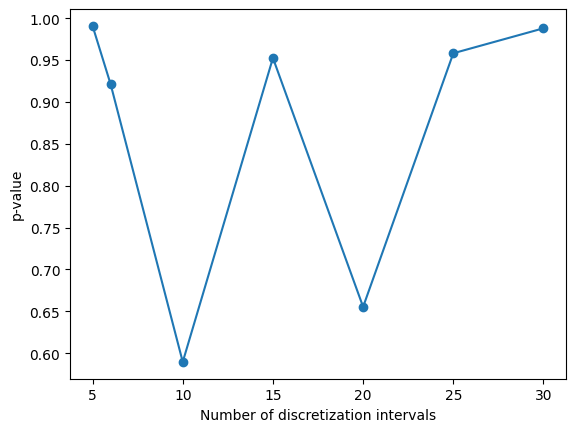

In [64]:
data = np.array([164, 142, 110, 153, 103, 52, 174, 88, 178, 184, 58, 62, 132, 128])
num_intervals_vec = [5, 6, 10, 15, 20, 25, 30]
p_val_vec = []
for num_intervals in num_intervals_vec:
    p_val = get_p_val(data, num_intervals, lb, ub)
    p_val_vec.append(p_val)

plt.plot(num_intervals_vec, p_val_vec, "-o")
plt.xlabel("Number of discretization intervals")
plt.ylabel("p-value")
plt.show()

### Q5

In [87]:
# data = [86, 133, 75, 22, 11, 144, 78, 122, 8, 146, 33, 41, 99]
# lmda = 1/50
# N = len(data)
# v1 = np.sort(data)
# intervals = [0, 10, 20, 30, 50, 100, 200, 400]
# obs = discretize(v1, intervals)/N
# obs = np.cumsum(obs)
# print(obs)
# exp = np.array([1-math.exp(-lmda*x) for x in intervals[1:]])
# print(exp)

In [ ]:
# cnt = 0
# y = np.random.rand()
# for i in range(n):
#     u = np.random.rand()
#     if(u<=y):
#         cnt += 1
# val = abs(cnt/n - y)
# if(val>d):
#     ans = 1 

In [10]:
data = [86, 133, 75, 22, 11, 144, 78, 122, 8, 146, 33, 41, 99]
lmda = 1/50
N = len(data)
data_sorted = np.sort(data)

# Computing D-stat
d = compute_max_difference(data_sorted, lambda x: F_exp(x, lmda))
print("Test Statistic: ", d)

num_iters = 10000
nmr = 0
# Computing p-value
for itr in range(num_iters):
    uniform = [np.random.rand() for _ in range(N)]
    uniform_sorted = np.sort(uniform)
    lhs = compute_max_difference(uniform_sorted, F_unif)
    # proportion of times when something more extreme (than our d-stat) is observed
    if(lhs>=d): # lhs>d => something as extreme as our test stat is observed
        nmr += 1
p_value = nmr/num_iters
print("p-value:", p_value)

Test Statistic:  0.3922544552361856
p-value: 0.0233


In [97]:
# N = 4
# uniform = [np.random.rand() for _ in range(N)]
# print(uniform)
# uniform_sorted = np.sort(uniform)
# print(uniform_sorted)
# lhs = compute_max_difference(uniform_sorted, F_unif, N)
# print(lhs)

### Q12

In [164]:
# treatment_values = np.array([19, 31, 39, 45, 47, 66, 75])
# control_values = np.array([28, 36, 44, 49, 52, 72, 72])
# mu_t, mu_c = treatment_values.mean(), control_values.mean()
# print(mu_t, mu_c)

In [165]:
# all_values = np.concatenate([treatment_values, control_values])
# std = all_values.std() # /n (sample std)
# print(std)

In [11]:
# First set
treatment_values = np.array([19, 31, 39, 45, 47, 66, 75])
# Second set: although 2 values are same here, since they are in the same set, does not matter in the computations!
control_values = np.array([28, 36, 44, 49, 52, 72, 72]) 
all_values = np.concatenate([treatment_values, control_values])
all_values = np.sort(all_values)

R_tmt = []
R_ctrl = []
for val in treatment_values:
    R_tmt.append(np.where(all_values == val)[0][0] + 1)
for val in control_values:
    R_ctrl.append(np.where(all_values == val)[0][0] + 1)

R_tmt = np.array(R_tmt)
Rt_sum = R_tmt.sum()
print("Treatment Rank Sum:", Rt_sum)
R_ctrl = np.array(R_ctrl)
Rc_sum = R_ctrl.sum()
print("Control Rank Sum:", Rc_sum)

Treatment Rank Sum: 49
Control Rank Sum: 55


In [13]:
r = Rt_sum
n = len(treatment_values)
m = len(control_values)
Pmat = {}
P_less_than = get_prob_dp_memoize(n, m, r, Pmat)
P_greater_than = 1- get_prob_dp_memoize(n, m, r-1, Pmat)
p_value = 2*min(P_less_than, P_greater_than)
print("exact p_value using recursion:", p_value)

exact p_value using recursion: 0.7593240093240093


### Q13

#### (a)

In [14]:
rmean = n*(n+m+1)/2
rvar = n*m*(n+m+1)/12
rstar = (r - rmean)/math.sqrt(rvar)
if(r<=rmean):
    p_val = 2*norm.cdf(rstar)
else:
    p_val = 2*(1-norm.cdf(rstar))
print("p_value using normal approximation:", p_val)


p_value using normal approximation: 0.6547208460185769


#### (b)

In [15]:
def get_subset(universe, size):
    val_to_posn = []
    for i in range(1, universe+1):
        u = np.random.rand()
        val_to_posn.append((u, i))
    val_to_posn = sorted(val_to_posn, key = lambda x: x[0])
    output = []
    for elm in range(size):
        output.append(val_to_posn[elm][1]) # add size number of elements to the output
    output = np.array(output)
    return output

num_iters = 10000
nmr = 0
for i in range(num_iters):
    subset = get_subset(n+m, n)
    # print(subset)
    subset_sum = subset.sum()
    if(subset_sum <= r):
        nmr += 1
p1 = nmr/num_iters
p2 = 1-p1
p_val = 2*min(p1, p2)
print("p_value using simulation:", p_val)

p_value using simulation: 0.7208


### Q17

In [180]:
# tarrival = [0, 12, 20, 33, 44, 55, 56, 61, 63, 66, 70, 73, 75, 78, 80, 82, 85, 87, 90]
# lta = len(tarrival)
# arrival_delta = [] # vector of differences of time arrivals
# for i in range(lta-1):
#     arrival_delta.append(tarrival[i+1]-tarrival[i])
# lad = len(arrival_delta)
# # mean of interarrival intervals
# arrival_delta_mean = (tarrival[-1]-tarrival[0])/(lta-1)
# # standard deviation of interarrival intervals
# arrival_delta_std = 0
# for i in range(lad):
#     arrival_delta_std += (arrival_delta[i] - arrival_delta_mean)**2
# arrival_delta_std = math.sqrt(arrival_delta_std/lad)
# print(arrival_delta_mean, arrival_delta_std)

In [179]:
# arrival_delta_se = arrival_delta_std/math.sqrt(lad)
# tstat = (arrival_delta_mean - 100/18)/arrival_delta_se
# print(tstat)

In [16]:
tarrival = [12, 20, 33, 44, 55, 56, 61, 63, 66, 70, 73, 75, 78, 80, 82, 85, 87, 90]
N = len(tarrival)
period = 100
# Dividing by period to make the values belong to U[0, 1]
tarrival = np.array(tarrival)/period

# Computing D-stat
d = compute_max_difference(tarrival, F_unif)
print("Test Statistic: ", d)

num_iters = 10000
nmr = 0
# Computing p-value
for itr in range(num_iters):
    uniform = [np.random.rand() for _ in range(N)]
    uniform_sorted = np.sort(uniform)
    lhs = compute_max_difference(uniform_sorted, F_unif)
    # proportion of times when something more extreme (than our d-stat) is observed
    if(lhs>=d): # lhs>d => something as extreme as our test stat is observed
        nmr += 1
p_value = nmr/num_iters
print("p-value:", p_value)

Test Statistic:  0.32777777777777783
p-value: 0.0332
